In [537]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Libraries

In [538]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

import torch
import torch.nn as nn
import torch.optim as optim

# Read Dataset

In [539]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/adult_casestudy.csv'
df_adult = pd.read_csv(filepath)
df_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


# EDA

In [540]:
df_adult.shape

(48842, 15)

In [541]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [542]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


## Plot

In [543]:
num_cols = []
cat_cols = []

In [544]:
num_cols = df_adult.select_dtypes(include=['int','float']).columns
cat_cols = df_adult.select_dtypes(include=['object','bool']).columns

In [545]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [546]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

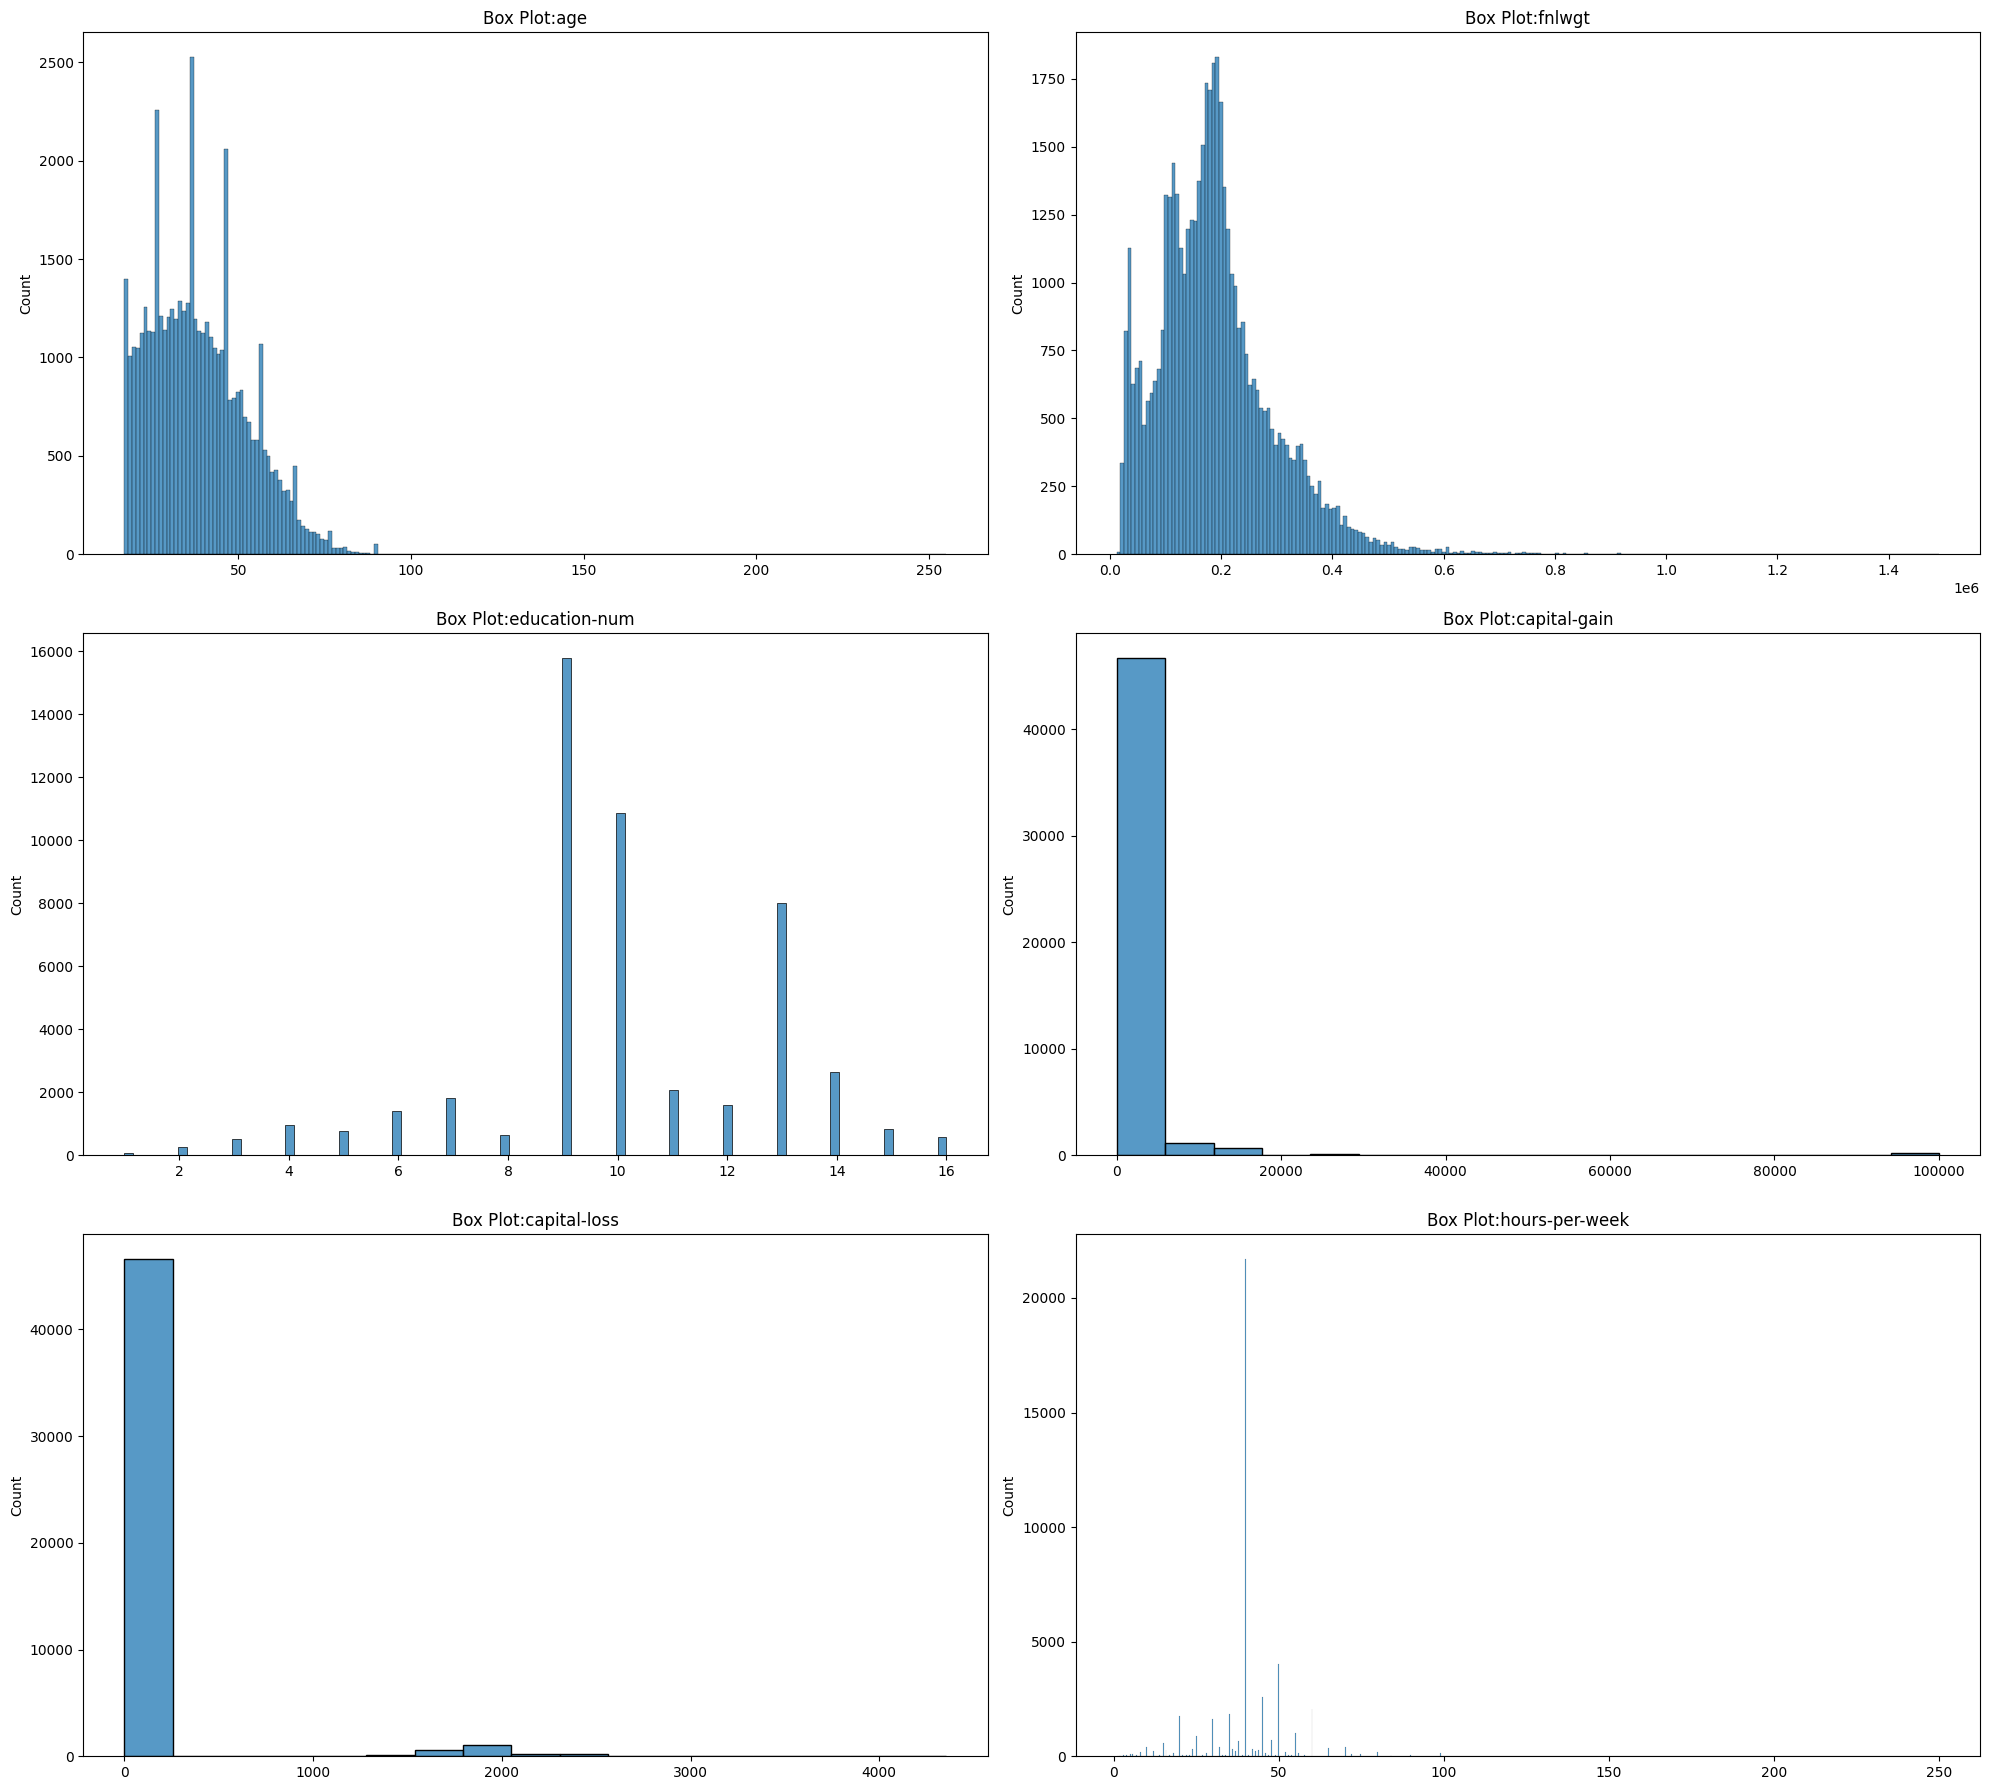

In [547]:
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

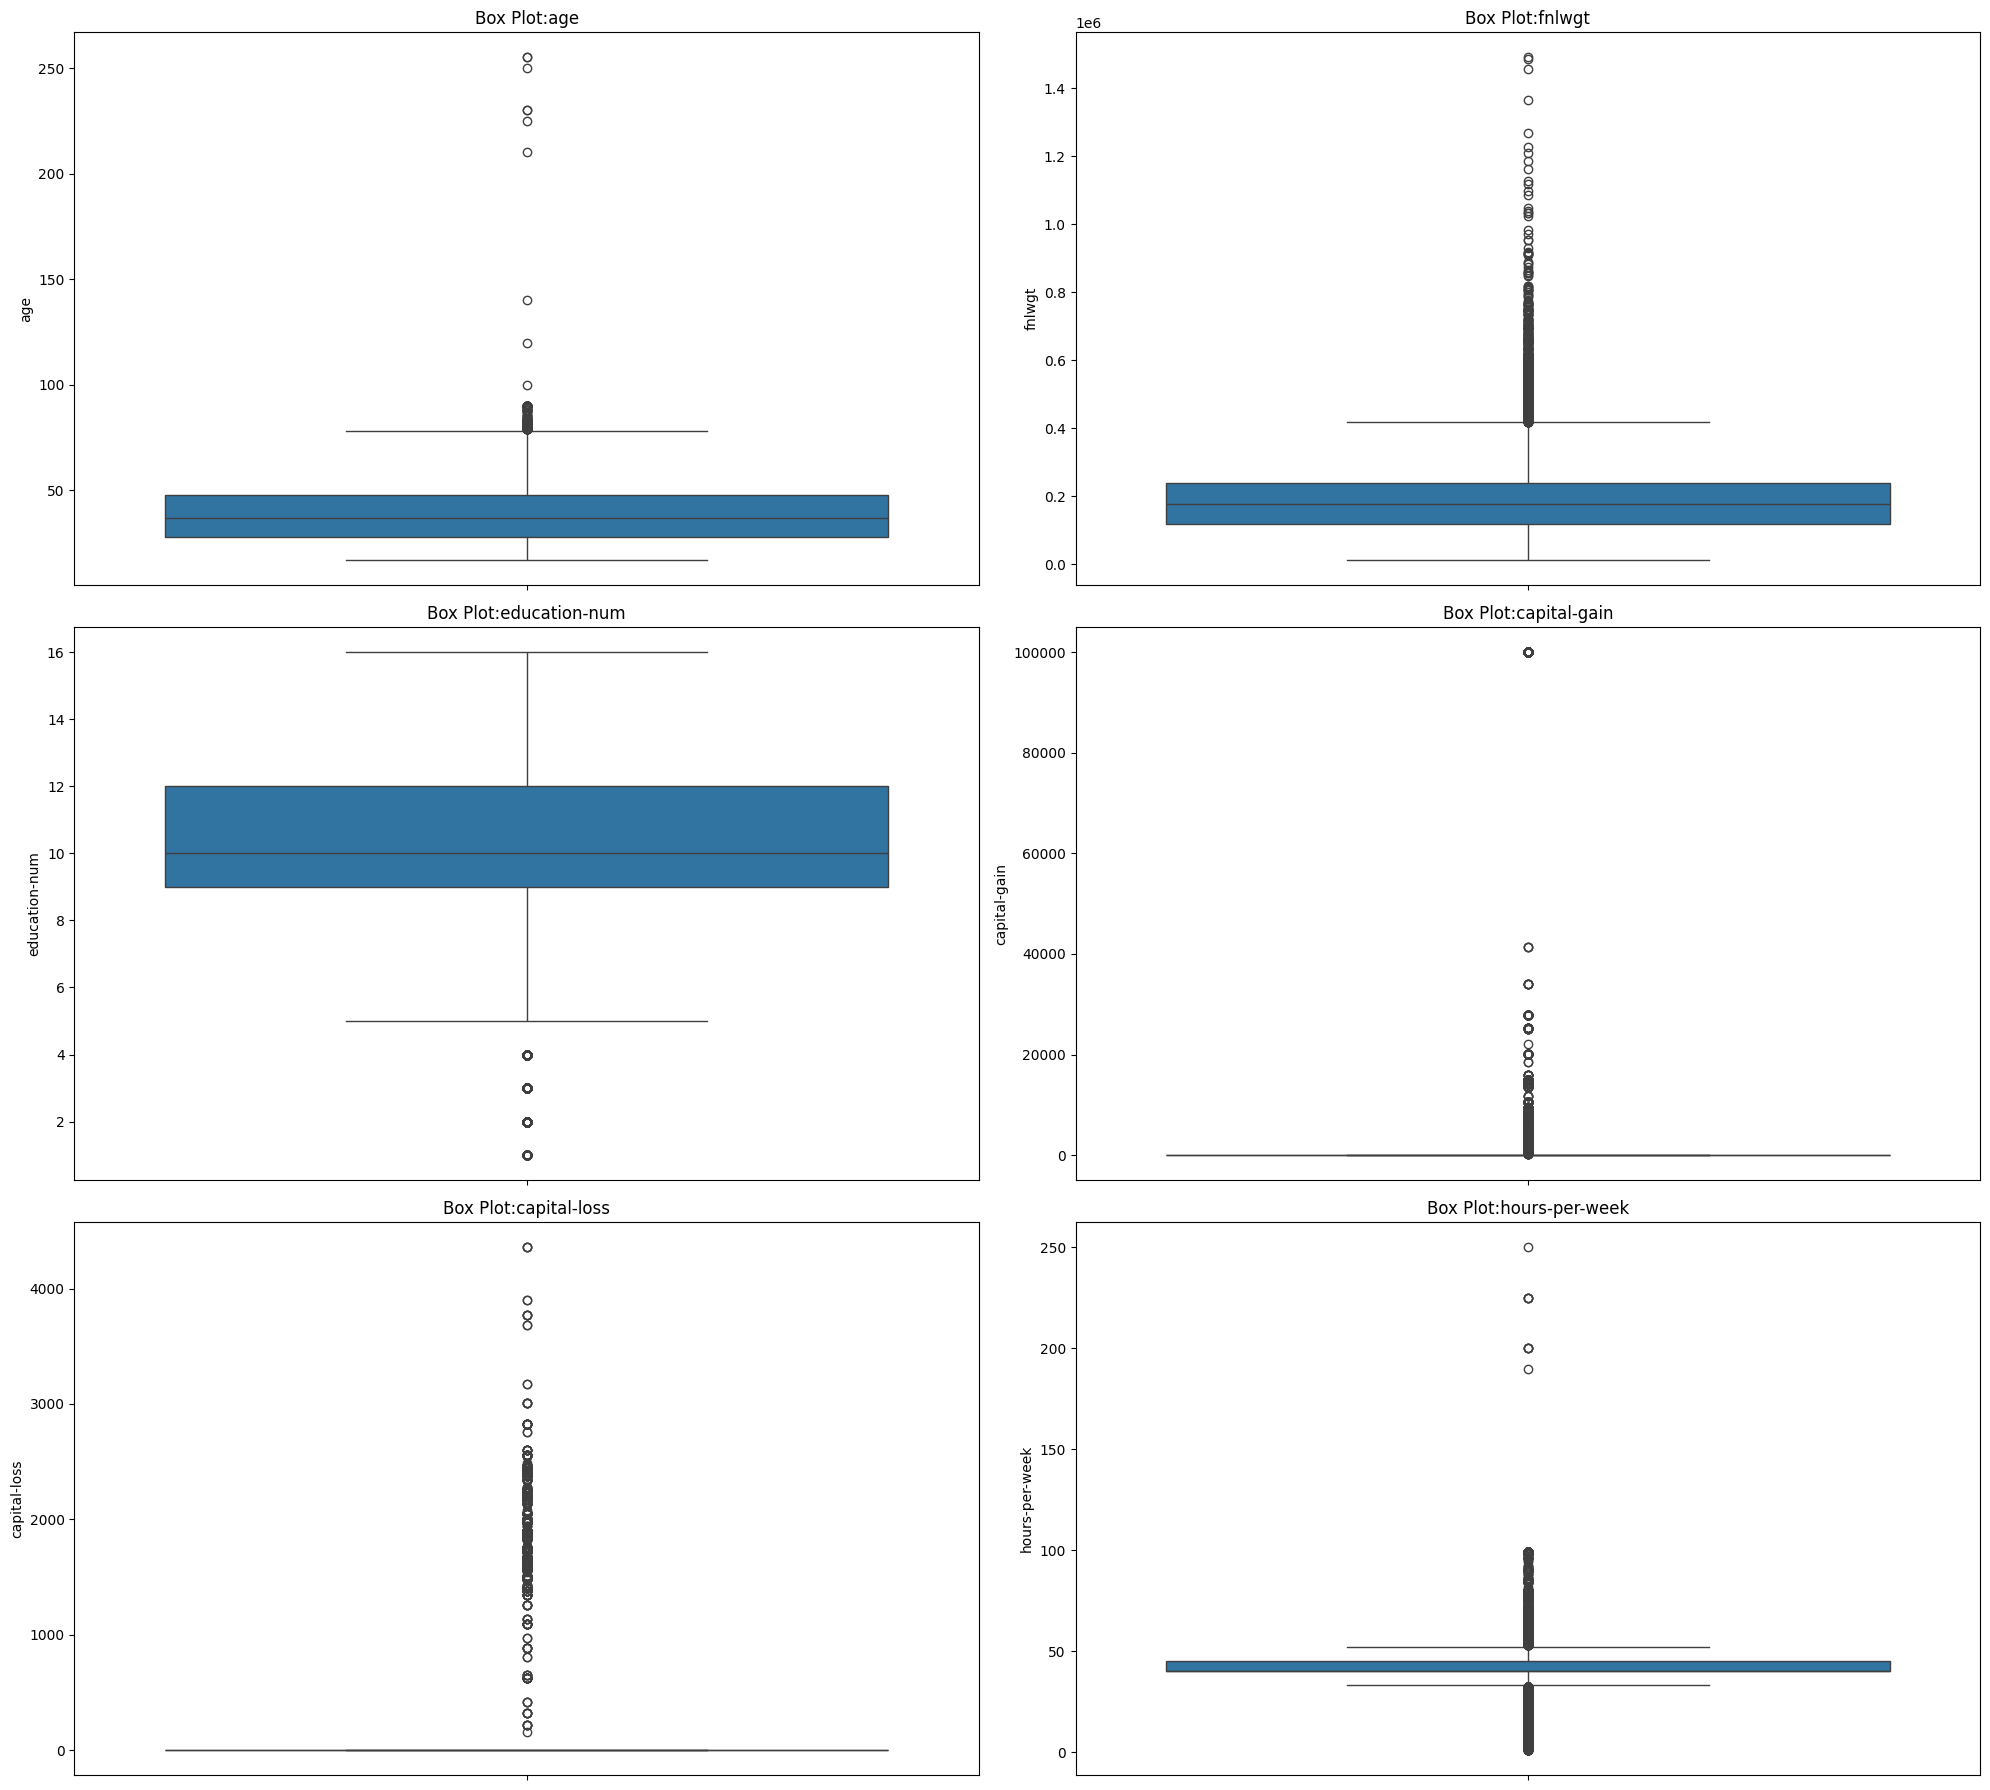

In [548]:
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

# Preprocessing

## Cleaning

### Duplicates

In [549]:
df_adult.duplicated().sum()

np.int64(16)

In [550]:
df_adult.drop_duplicates(inplace=True)


### Missing value

In [551]:
df_adult.isna().sum() # before handling

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [552]:
# Fill numerical missing values with median
df_adult['age'] = df_adult['age'].fillna(df_adult['age'].median())
df_adult['hours-per-week'] = df_adult['hours-per-week'].fillna(df_adult['hours-per-week'].median())

# Fill categorical missing values with mode
df_adult['workclass'] = df_adult['workclass'].fillna(df_adult['workclass'].mode()[0])
df_adult['occupation'] = df_adult['occupation'].fillna(df_adult['occupation'].mode()[0])
df_adult['native-country'] = df_adult['native-country'].fillna(df_adult['native-country'].mode()[0])

In [553]:
df_adult.isna().sum() # after handling

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [554]:
df_adult.drop('education', axis=1, inplace=True) # dropped because education num is also gives same info

In [555]:
df_adult.drop('race', axis=1, inplace=True) # race is not important factor

In [556]:
df_adult.drop('native-country', axis=1, inplace=True) # low importance

In [557]:
df_adult.drop('fnlwgt', axis=1, inplace=True) # census weight not important

### Outlier Handling

In [558]:
outlier_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

for i in outlier_cols:
  Q1 = df_adult[i].quantile(0.25)
  Q3 = df_adult[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")
  print(f"Lower Bound: {lower_bound}")
  print(f"Upper Bound: {upper_bound}")

Q1: 28.0
Q3: 47.0
IQR: 19.0
Lower Bound: -0.5
Upper Bound: 75.5
Q1: 9.0
Q3: 12.0
IQR: 3.0
Lower Bound: 4.5
Upper Bound: 16.5
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower Bound: 32.5
Upper Bound: 52.5


In [559]:
# clipping

for i in outlier_cols:
  Q1 = df_adult[i].quantile(0.25)
  Q3 = df_adult[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_adult[i] = df_adult[i].clip(lower_bound, upper_bound)
  outliers = ((df_adult[i] < lower_bound) | (df_adult[i] > upper_bound))
  print(f'outliers: {outliers.sum()}')

outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0


# Data Transformation

## Encoding

In [560]:
print("Unique income labels after cleaning:", df_adult['income'].unique())

le_income = LabelEncoder()
df_adult['income'] = le_income.fit_transform(df_adult['income'])
print("Encoded income classes:", df_adult['income'].unique())

le_sex = LabelEncoder()
df_adult['sex'] = le_sex.fit_transform(df_adult['sex'])


Unique income labels after cleaning: ['<=50K' '>50K' '<=50K.' '>50K.']
Encoded income classes: [0 2 1 3]


In [561]:
df_adult.head(2)

,age,workclass,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,income
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,1,0,0,40.0,0
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,1,0,0,32.5,0


In [562]:
one_hot_columns = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship'
]

df_adult = pd.get_dummies(
    df_adult,
    columns=one_hot_columns,
    drop_first=True,
    dtype=int
)

In [563]:
df.head(2)

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,39.0,13.0,1,0,0,40.0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,50.0,13.0,1,0,0,32.5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [564]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48826 non-null  float64
 1   education-num                         48826 non-null  float64
 2   sex                                   48826 non-null  int64  
 3   capital-gain                          48826 non-null  int64  
 4   capital-loss                          48826 non-null  int64  
 5   hours-per-week                        48826 non-null  float64
 6   income                                48826 non-null  int64  
 7   workclass_Federal-gov                 48826 non-null  int64  
 8   workclass_Local-gov                   48826 non-null  int64  
 9   workclass_Never-worked                48826 non-null  int64  
 10  workclass_Private                     48826 non-null  int64  
 11  workclass_Self-emp-i

## Train test split

In [565]:
X = df.drop('income', axis=1)
y = df['income']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (48826, 39)
y shape: (48826,)


In [566]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39060, 39)
X_test: (9766, 39)
y_train: (39060,)
y_test: (9766,)


## Scaling

In [567]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Tensorflow

In [568]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation = 'relu', input_shape=(39,)),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [569]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [570]:
import time
start_time = time.perf_counter()
history = model.fit(X_train,
    y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1
)
end_time = time.perf_counter()
print(f"Training time : {end_time - start_time:.4f} seconds")

Epoch 1/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3686 - loss: -430.1571 - val_accuracy: 0.3848 - val_loss: -1812.1771
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3744 - loss: -6422.6860 - val_accuracy: 0.3784 - val_loss: -13148.1816
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3766 - loss: -24170.1738 - val_accuracy: 0.3675 - val_loss: -37843.9805
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3668 - loss: -56448.2969 - val_accuracy: 0.3486 - val_loss: -78019.5078
Epoch 5/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3626 - loss: -105004.2031 - val_accuracy: 0.3542 - val_loss: -135691.3906
Epoch 6/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3650 - loss: -172126.5625 - val_accuracy: 0.3665 - val_loss: -212712.4688
Epoch 7/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3673 - loss: -259039.1875 - val_accuracy: 0.3669 - val_loss: -310430.2812
Epoch 8/50
977/977 ━━━━━━━━━━━━━

In [571]:
loss, accuracy = model_tf.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3317 - loss: -9157279.0000
Accuracy: 0.3316608667373657


In [572]:
print("Accuracy : ",accuracy)

Accuracy :  0.3316608667373657


# Pytorch

In [573]:
# convert every data into tensor
X_train_tensor = torch.FloatTensor(X_train)

X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1,1))

y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1,1))

In [574]:
class ANN(nn. Module) :
  def __init__ (self):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear (39,64),
      nn.ReLU(),
      nn.Linear(64,32),
      nn.ReLU(),
      nn.Linear(32,1),
      nn.Sigmoid()
    )
  def forward(self,x):
    return self.network(x)

In [575]:
model = ANN()

In [579]:
criterion = nn.BCELoss()

In [580]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [581]:
start_time = time.perf_counter()

y_train_tensor = ((y_train_tensor == 1) | (y_train_tensor == 3)).float()

epochs = 50
for epoch in range(epochs):
   outputs = model(X_train_tensor)
   loss = criterion(outputs,y_train_tensor)
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()
   if(epoch+1)%10 ==0:
    print(f"Epoch{epoch+1}",f"Loss={loss.item():.4f}")
end_time = time.perf_counter()

print(f"Training time  : {end_time - start_time:.4f} seconds")

Epoch10 Loss=0.6312
Epoch20 Loss=0.6275
Epoch30 Loss=0.6235
Epoch40 Loss=0.6196
Epoch50 Loss=0.6164
Training time  : 4.4032 seconds


In [582]:
df_adult.shape


(48826, 40)